# EA Sports FC 26 — Carga, limpieza y ordenación de datos

**Introducción a la Ciencia de Datos — Equipo Videojuegos**

**Objetivo de esta etapa:** dejar los datos listos y confiables para poder responder,
en la etapa siguiente, *¿qué atributos de la carta definen el OVR (media general)?*

Trabajamos con dos fuentes:

| Archivo | Qué es | Filas |
|---|---|---|
| `EAFC26.csv` | Cartas base de todos los jugadores del juego | 17.873 |
| `FC26_Promo_Players_-_promo_cards.csv` | Cartas promocionales (TOTY, TOTS, TOTW, Future Stars) | 212 |

El notebook está dividido en tres partes, que son exactamente las tres cosas que
tenemos que presentar:

1. **CARGA** — leer los archivos y mirarlos por primera vez.
2. **LIMPIEZA** — arreglar tipos, nulos, duplicados y columnas mal formateadas.
3. **ORDENACIÓN** — dejar las columnas y las filas en un orden lógico y exportar.

## 0. Preparación del entorno

Importamos las librerías y definimos las rutas. Usamos rutas **relativas** (`../data/...`)
para que el proyecto funcione en la computadora de cualquier integrante del equipo
cuando lo clone desde GitHub.

In [1]:
import ast
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

# Que pandas nos muestre las tablas anchas sin cortar columnas
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

# Rutas del proyecto.
# Buscamos hacia arriba la carpeta que contiene "data", así el notebook funciona
# tanto si lo ejecutás desde notebooks/ como desde la raíz del repositorio.
DIR_BASE = Path.cwd()
for carpeta in [DIR_BASE, *DIR_BASE.parents]:
    if (carpeta / "data" / "raw").is_dir():
        DIR_BASE = carpeta
        break
else:
    raise FileNotFoundError(
        "No encuentro la carpeta data/raw. Revisá que estés dentro del repositorio "
        "y que los CSV estén en data/raw/."
    )

DIR_CRUDO = DIR_BASE / "data" / "raw"
DIR_LIMPIO = DIR_BASE / "data" / "processed"
DIR_LIMPIO.mkdir(parents=True, exist_ok=True)

print("Proyecto en:", DIR_BASE)
print("Datos crudos en:", DIR_CRUDO)
print("Datos limpios se guardarán en:", DIR_LIMPIO)

Proyecto en: /Users/manulussich/Documents/GitHub/Lab_Equipo_Videojuegos
Datos crudos en: /Users/manulussich/Documents/GitHub/Lab_Equipo_Videojuegos/data/raw
Datos limpios se guardarán en: /Users/manulussich/Documents/GitHub/Lab_Equipo_Videojuegos/data/processed


---
# PARTE 1 — CARGA

Cargar no es sólo "abrir el archivo": es abrirlo y **verificar que se leyó bien**.
Antes de tocar nada, miramos qué tenemos.

## 1.1 Leer los archivos CSV

In [2]:
jugadores_crudo = pd.read_csv(DIR_CRUDO / "EAFC26.csv", encoding="utf-8")
promo_crudo = pd.read_csv(DIR_CRUDO / "FC26_Promo_Players_-_promo_cards.csv", encoding="utf-8")

print(f"Jugadores: {jugadores_crudo.shape[0]:,} filas x {jugadores_crudo.shape[1]} columnas")
print(f"Cartas promo: {promo_crudo.shape[0]:,} filas x {promo_crudo.shape[1]} columnas")

Jugadores: 17,873 filas x 59 columnas
Cartas promo: 212 filas x 10 columnas


## 1.2 Primera mirada al dataset de jugadores

In [3]:
jugadores_crudo.head(3)

,ID,Rank,Name,GENDER,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Position,Weak foot,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,card
0,209331,1,Mohamed Salah,M,91,89,88,86,90,45,76,88,89,93,94,83,78,83,88,86,89,69,88,81,88,90,86,91,94,90,93,55,59,38,43,41,79,88,75,63,RM,3,4,Left,"175cm / 5'9""",72kg / 159lb,['RW'],33,Egypt,Premier League,Liverpool,"['Finesse Shot+', 'First Touch', 'Gamechanger'...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,https://ratings-images-prod.pulse.ea.com/FC26/...
1,227203,2,Alexia Putellas,F,91,82,89,90,91,72,80,81,82,91,91,86,88,87,89,88,92,85,91,90,89,91,90,89,91,92,92,78,74,60,81,64,85,85,81,70,CM,5,5,Left,"173cm / 5'8""",68kg / 150lb,"['CAM', 'CDM']",32,Spain,Liga F Moeve,FC Barcelona,"['First Touch+', 'Finesse Shot', 'Gamechanger'...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,https://ratings-images-prod.pulse.ea.com/FC26/...
2,231747,3,Kylian Mbappé,M,91,97,90,81,92,37,76,97,97,91,92,91,86,87,82,78,83,69,87,74,80,92,93,82,91,93,88,38,78,26,34,32,90,83,77,61,ST,4,5,Right,"182cm / 6'0""",75kg / 165lb,"['LW', 'LM']",27,France,LALIGA EA SPORTS,Real Madrid,"['Quick Step+', 'Acrobatic', 'Finesse Shot', '...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,https://ratings-images-prod.pulse.ea.com/FC26/...


In [4]:
# Nombres de las columnas tal como vienen del archivo
print(list(jugadores_crudo.columns))

['ID', 'Rank', 'Name', 'GENDER', 'OVR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Acceleration', 'Sprint Speed', 'Positioning', 'Finishing', 'Shot Power', 'Long Shots', 'Volleys', 'Penalties', 'Vision', 'Crossing', 'Free Kick Accuracy', 'Short Passing', 'Long Passing', 'Curve', 'Dribbling', 'Agility', 'Balance', 'Reactions', 'Ball Control', 'Composure', 'Interceptions', 'Heading Accuracy', 'Def Awareness', 'Standing Tackle', 'Sliding Tackle', 'Jumping', 'Stamina', 'Strength', 'Aggression', 'Position', 'Weak foot', 'Skill moves', 'Preferred foot', 'Height', 'Weight', 'Alternative positions', 'Age', 'Nation', 'League', 'Team', 'play style', 'url', 'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes', 'card']


Las columnas se agrupan en cinco bloques:

- **Identidad:** `ID`, `Name`, `GENDER`, `Age`, `Position`, `Alternative positions`
- **Cara de la carta (las 6 caras que ves en Ultimate Team):** `OVR`, `PAC`, `SHO`, `PAS`, `DRI`, `DEF`, `PHY`
- **Atributos detallados (29):** `Acceleration`, `Finishing`, `Vision`, `Composure`, etc.
- **Características de la carta:** `Weak foot`, `Skill moves`, `Preferred foot`, `Height`, `Weight`, `play style`
- **Contexto:** `Nation`, `League`, `Team`, y dos URLs

## 1.3 Diagnóstico de calidad de los datos

Esta es la parte clave de la carga: **buscar los problemas antes de limpiar**.
Si no los listamos primero, limpiamos a ciegas.

In [5]:
# ¿Cuántos valores faltan en cada columna?
nulos = jugadores_crudo.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print("Columnas con valores faltantes:\n")
print(nulos.to_string())

Columnas con valores faltantes:

GK Diving                15859
GK Handling              15859
GK Positioning           15859
GK Kicking               15859
GK Reflexes              15859
Alternative positions     6380


In [6]:
# ¿Hay filas repetidas?
print("Filas idénticas duplicadas:", jugadores_crudo.duplicated().sum())
print("IDs de jugador duplicados:", jugadores_crudo["ID"].duplicated().sum())

Filas idénticas duplicadas: 0
IDs de jugador duplicados: 0


In [7]:
# ¿Qué tipo de dato detectó pandas en cada columna?
tipos = jugadores_crudo.dtypes.value_counts()
print(tipos.to_string())
print("\nColumnas que deberían ser números pero pandas leyó como texto:")
print(jugadores_crudo[["Height", "Weight", "Alternative positions", "play style"]].head(3).to_string())

int64      41
str        13
float64     5

Columnas que deberían ser números pero pandas leyó como texto:
         Height        Weight Alternative positions                                                                                                    play style
0  175cm / 5'9"  72kg / 159lb                ['RW']  ['Finesse Shot+', 'First Touch', 'Gamechanger', 'Inventive', 'Low Driven Shot', 'Technical', 'Whipped Pass']
1  173cm / 5'8"  68kg / 150lb        ['CAM', 'CDM']       ['First Touch+', 'Finesse Shot', 'Gamechanger', 'Incisive Pass', 'Inventive', 'Technical', 'Tiki Taka']
2  182cm / 6'0"  75kg / 165lb          ['LW', 'LM']        ['Quick Step+', 'Acrobatic', 'Finesse Shot', 'First Touch', 'Gamechanger', 'Low Driven Shot', 'Rapid']


### Problemas detectados

| # | Problema | Dónde | Cómo lo vamos a resolver |
|---|---|---|---|
| 1 | Nombres de columnas inconsistentes (`ID`, `GENDER`, `play style`, `Sprint Speed`) | Todas | Normalizar todo a `snake_case` |
| 2 | `Height` y `Weight` son texto (`"175cm / 5'9\""`) | 2 columnas | Extraer el número en cm y kg |
| 3 | `Alternative positions` y `play style` son listas guardadas como texto | 2 columnas | Convertir a lista real y contar |
| 4 | 15.859 nulos en las 5 columnas `GK *` | 5 columnas | **No es un error:** sólo los arqueros tienen esos datos |
| 5 | 6.380 nulos en `Alternative positions` | 1 columna | **No es un error:** son jugadores de una sola posición → lista vacía |
| 6 | Los arqueros usan la misma columna para otra cosa | 2.014 filas | Separarlos en un dataset propio (ver 2.8) |
| 7 | Columnas inútiles para el análisis (`url`, `card`, `Rank`) | 3 columnas | Quitarlas |

> **Ojo con `Rank`:** es simplemente el puesto del jugador ordenado por OVR. Si la
> dejáramos, estaríamos "haciendo trampa": predeciría el OVR perfectamente porque
> *sale* del OVR. En ciencia de datos a esto se le llama **fuga de información
> (data leakage)** y hay que eliminarla.

## 1.4 El detalle más importante: los arqueros

En EA FC, la carta de un arquero muestra **DIV / HAN / KIC / REF / SPD / POS**
en lugar de **PAC / SHO / PAS / DRI / DEF / PHY**, pero el CSV guarda los dos
en las mismas columnas. Lo comprobamos:

In [8]:
arqueros_check = jugadores_crudo[jugadores_crudo["Position"] == "GK"]

equivalencias = {
    "PAC": "GK Diving",
    "SHO": "GK Handling",
    "PAS": "GK Kicking",
    "DRI": "GK Reflexes",
    "PHY": "GK Positioning",
}
for col_campo, col_gk in equivalencias.items():
    iguales = (arqueros_check[col_campo] == arqueros_check[col_gk]).all()
    print(f"Para arqueros, ¿{col_campo} es lo mismo que '{col_gk}'? → {iguales}")

print("\n(La columna DEF de un arquero es su velocidad/SPD: no tiene columna 'GK Speed' propia.)")

Para arqueros, ¿PAC es lo mismo que 'GK Diving'? → True
Para arqueros, ¿SHO es lo mismo que 'GK Handling'? → True
Para arqueros, ¿PAS es lo mismo que 'GK Kicking'? → True
Para arqueros, ¿DRI es lo mismo que 'GK Reflexes'? → True
Para arqueros, ¿PHY es lo mismo que 'GK Positioning'? → True

(La columna DEF de un arquero es su velocidad/SPD: no tiene columna 'GK Speed' propia.)


**Conclusión:** mezclar arqueros y jugadores de campo en el mismo análisis daría
correlaciones falsas, porque `PAC=90` significa "rápido" en un delantero y
"buenas estiradas" en un arquero. Por eso en la limpieza los vamos a separar.

## 1.5 Primera mirada al dataset de cartas promocionales

In [9]:
promo_crudo.head(5)

,player_id,player_name,team,promo_code,drop_label,card_ovr,release_date,acquisition,is_tradeable,notes
0,NaN,Kylian Mbappe,Real Madrid,TOTY,Men's TOTY,96,2026-01-16,pack,True,NaN
1,NaN,Alexia Putellas,FC Barcelona,TOTY,Women's TOTY,95,2026-01-18,pack,True,NaN
2,NaN,Aitana Bonmati,FC Barcelona,TOTY,Women's TOTY,97,2026-01-18,pack,True,NaN
3,NaN,Ousmane Dembele,Paris SG,TOTY,Men's TOTY,97,2026-01-16,pack,True,NaN
4,NaN,Alessia Russo,Arsenal,TOTY,Women's TOTY,97,2026-01-16,pack,True,NaN


In [10]:
print("Valores faltantes por columna:")
print(promo_crudo.isna().sum().to_string())
print("\nCartas por tipo de promo:")
print(promo_crudo["promo_code"].value_counts().to_string())

Valores faltantes por columna:
player_id       212
player_name       0
team              0
promo_code        0
drop_label        0
card_ovr          0
release_date      0
acquisition       0
is_tradeable      0
notes           212

Cartas por tipo de promo:
promo_code
TOTS            80
Future Stars    62
TOTW            46
TOTY            24


Problemas: `player_id` y `notes` están **100% vacías** (212 de 212) y `release_date`
es texto en vez de fecha. Además, no hay un ID para unir con el dataset principal:
vamos a tener que cruzarlo por nombre, y los nombres vienen sin tildes
(`Kylian Mbappe` vs `Kylian Mbappé`).

---
# PARTE 2 — LIMPIEZA

Regla de oro: **nunca modificar el dataset crudo.** Trabajamos sobre una copia,
así siempre podemos volver atrás y comparar.

In [11]:
jugadores = jugadores_crudo.copy()
promo = promo_crudo.copy()

filas_iniciales = len(jugadores)
print(f"Partimos de {filas_iniciales:,} jugadores.")

Partimos de 17,873 jugadores.


## 2.1 Normalizar los nombres de las columnas

Pasamos todo a `snake_case`: minúsculas, sin espacios, sin mayúsculas sueltas.
Así podemos escribir `df.sprint_speed` en vez de `df["Sprint Speed"]` y evitamos
errores de tipeo.

In [12]:
def a_snake_case(nombre: str) -> str:
    """Convierte 'Sprint Speed' -> 'sprint_speed' y 'GK Diving' -> 'gk_diving'."""
    nombre = nombre.strip().lower()
    nombre = re.sub(r"[^\w]+", "_", nombre)  # espacios y símbolos -> guion bajo
    return nombre.strip("_")


# Algunos nombres merecen ser más explícitos que su traducción automática
RENOMBRES_ESPECIALES = {
    "id": "player_id",
    "play_style": "play_styles",
    "card": "card_image_url",
}

jugadores.columns = [a_snake_case(c) for c in jugadores.columns]
jugadores = jugadores.rename(columns=RENOMBRES_ESPECIALES)

promo.columns = [a_snake_case(c) for c in promo.columns]

print(list(jugadores.columns))

['player_id', 'rank', 'name', 'gender', 'ovr', 'pac', 'sho', 'pas', 'dri', 'def', 'phy', 'acceleration', 'sprint_speed', 'positioning', 'finishing', 'shot_power', 'long_shots', 'volleys', 'penalties', 'vision', 'crossing', 'free_kick_accuracy', 'short_passing', 'long_passing', 'curve', 'dribbling', 'agility', 'balance', 'reactions', 'ball_control', 'composure', 'interceptions', 'heading_accuracy', 'def_awareness', 'standing_tackle', 'sliding_tackle', 'jumping', 'stamina', 'strength', 'aggression', 'position', 'weak_foot', 'skill_moves', 'preferred_foot', 'height', 'weight', 'alternative_positions', 'age', 'nation', 'league', 'team', 'play_styles', 'url', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning', 'gk_reflexes', 'card_image_url']


## 2.2 Eliminar columnas que no aportan al análisis

In [13]:
COLUMNAS_A_ELIMINAR = [
    "rank",            # fuga de información: se calcula a partir del OVR
    "url",             # link a la web de EA
    "card_image_url",  # link a la imagen de la carta
]

jugadores = jugadores.drop(columns=COLUMNAS_A_ELIMINAR)
print(f"Eliminamos {len(COLUMNAS_A_ELIMINAR)} columnas. Quedan {jugadores.shape[1]}.")

Eliminamos 3 columnas. Quedan 56.


## 2.3 Convertir altura y peso a números

Vienen como `"175cm / 5'9\""` y `"72kg / 159lb"`. Nos quedamos con el sistema
métrico y descartamos el imperial, que es información repetida.

In [14]:
def extraer_numero(texto: str, unidad: str) -> float:
    """De '175cm / 5\\'9\"' con unidad 'cm' devuelve 175.0. Si no encuentra nada, NaN."""
    if pd.isna(texto):
        return np.nan
    encontrado = re.search(rf"(\d+)\s*{unidad}", str(texto))
    return float(encontrado.group(1)) if encontrado else np.nan


jugadores["height_cm"] = jugadores["height"].apply(lambda x: extraer_numero(x, "cm"))
jugadores["weight_kg"] = jugadores["weight"].apply(lambda x: extraer_numero(x, "kg"))

# Verificamos que no se haya roto ninguna conversión antes de borrar las originales
assert jugadores["height_cm"].notna().all(), "Hay alturas que no se pudieron convertir"
assert jugadores["weight_kg"].notna().all(), "Hay pesos que no se pudieron convertir"

jugadores = jugadores.drop(columns=["height", "weight"])

print(jugadores[["height_cm", "weight_kg"]].describe().round(1).to_string())

       height_cm  weight_kg
count    17873.0    17873.0
mean       180.9       73.9
std          7.8        8.0
min        151.0       45.0
25%        175.0       69.0
50%        181.0       74.0
75%        187.0       79.0
max        210.0      105.0


## 2.4 Convertir las listas de texto en datos usables

`alternative_positions` y `play_styles` vienen como `"['RW', 'LM']"`: es texto que
*parece* una lista. `ast.literal_eval` la convierte en una lista de Python de
forma segura.

In [15]:
def texto_a_lista(valor) -> list:
    """Convierte la cadena \"['RW', 'LM']\" en la lista ['RW', 'LM']. NaN -> []."""
    if pd.isna(valor):
        return []
    if isinstance(valor, list):
        return valor
    try:
        resultado = ast.literal_eval(str(valor))
        return list(resultado) if isinstance(resultado, (list, tuple)) else []
    except (ValueError, SyntaxError):
        return []


jugadores["alternative_positions"] = jugadores["alternative_positions"].apply(texto_a_lista)
jugadores["play_styles"] = jugadores["play_styles"].apply(texto_a_lista)

# De cada lista sacamos variables numéricas, que sí se pueden analizar
jugadores["n_alternative_positions"] = jugadores["alternative_positions"].str.len()
jugadores["n_play_styles"] = jugadores["play_styles"].str.len()
# Los PlayStyle terminados en '+' son los "PlayStyle+", la versión mejorada
jugadores["n_play_styles_plus"] = jugadores["play_styles"].apply(
    lambda lista: sum(1 for ps in lista if str(ps).endswith("+"))
)

print(jugadores[["n_alternative_positions", "n_play_styles", "n_play_styles_plus"]].describe().round(2).to_string())

       n_alternative_positions  n_play_styles  n_play_styles_plus
count                 17873.00       17873.00            17873.00
mean                      1.04           0.95                0.01
std                       0.94           1.38                0.10
min                       0.00           0.00                0.00
25%                       0.00           0.00                0.00
50%                       1.00           0.00                0.00
75%                       2.00           1.00                0.00
max                       3.00           7.00                1.00


## 2.5 Tratar los valores faltantes

Un nulo no siempre es un error. Acá tenemos dos casos distintos y se tratan distinto:

- `alternative_positions` vacío → el jugador juega en **una sola** posición. Ya quedó
  resuelto en el paso anterior: la lista vacía `[]` es el dato correcto, no un faltante.
- Columnas `gk_*` vacías → el jugador **no es arquero**. Esas columnas van a
  desaparecer del dataset de campo, así que el nulo desaparece solo.

In [16]:
COLUMNAS_GK = ["gk_diving", "gk_handling", "gk_kicking", "gk_positioning", "gk_reflexes"]

print("Nulos en gk_* que NO son arqueros:",
      jugadores.loc[jugadores["position"] != "GK", COLUMNAS_GK].isna().all().all())
print("Arqueros sin datos de gk_*:",
      jugadores.loc[jugadores["position"] == "GK", COLUMNAS_GK].isna().sum().sum())

nulos_restantes = jugadores.isna().sum()
print("\nColumnas con nulos que quedan (deberían ser sólo las gk_*):")
print(nulos_restantes[nulos_restantes > 0].to_string())

Nulos en gk_* que NO son arqueros: True
Arqueros sin datos de gk_*: 0

Columnas con nulos que quedan (deberían ser sólo las gk_*):
gk_diving         15859
gk_handling       15859
gk_kicking        15859
gk_positioning    15859
gk_reflexes       15859


## 2.6 Duplicados

Ya vimos que no hay filas idénticas ni IDs repetidos. Chequeamos también por la
combinación nombre + equipo + edad, por si un mismo jugador entró dos veces con
distinto ID.

In [17]:
dup_id = jugadores["player_id"].duplicated().sum()
dup_persona = jugadores.duplicated(subset=["name", "team", "age"]).sum()
print(f"Duplicados por player_id: {dup_id}")
print(f"Duplicados por nombre + equipo + edad: {dup_persona}")

if dup_id or dup_persona:
    jugadores = jugadores.drop_duplicates(subset=["player_id"]).reset_index(drop=True)
    print(f"→ Eliminados. Quedan {len(jugadores):,} jugadores.")
else:
    print("→ No hay duplicados que eliminar.")

Duplicados por player_id: 0
Duplicados por nombre + equipo + edad: 0
→ No hay duplicados que eliminar.


## 2.7 Validar rangos y tipos

Los atributos de EA FC van de 0 a 99, la edad tiene que ser razonable, y el pie
preferido sólo puede ser izquierdo o derecho. Si algo se sale de rango, es un
error de datos.

In [18]:
ATRIBUTOS_CARA = ["pac", "sho", "pas", "dri", "def", "phy"]
ATRIBUTOS_DETALLE = [
    "acceleration", "sprint_speed", "positioning", "finishing", "shot_power",
    "long_shots", "volleys", "penalties", "vision", "crossing", "free_kick_accuracy",
    "short_passing", "long_passing", "curve", "dribbling", "agility", "balance",
    "reactions", "ball_control", "composure", "interceptions", "heading_accuracy",
    "def_awareness", "standing_tackle", "sliding_tackle", "jumping", "stamina",
    "strength", "aggression",
]
TODOS_LOS_ATRIBUTOS = ["ovr"] + ATRIBUTOS_CARA + ATRIBUTOS_DETALLE

fuera_de_rango = {
    col: int(((jugadores[col] < 0) | (jugadores[col] > 99)).sum())
    for col in TODOS_LOS_ATRIBUTOS
}
problemas = {c: n for c, n in fuera_de_rango.items() if n > 0}
print("Atributos fuera del rango 0-99:", problemas if problemas else "ninguno ✓")

print("\nEdad: de", jugadores["age"].min(), "a", jugadores["age"].max(), "años")
print("Pie preferido:", sorted(jugadores["preferred_foot"].unique()))
print("Weak foot (estrellas):", sorted(jugadores["weak_foot"].unique()))
print("Skill moves (estrellas):", sorted(jugadores["skill_moves"].unique()))

Atributos fuera del rango 0-99: ninguno ✓

Edad: de 17 a 44 años
Pie preferido: ['Left', 'Right']
Weak foot (estrellas): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Skill moves (estrellas): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [19]:
# Las variables de texto con pocos valores distintos se guardan como 'category':
# ocupan mucha menos memoria y dejan claro que son categóricas, no texto libre.
COLUMNAS_CATEGORICAS = ["gender", "position", "preferred_foot", "nation", "league", "team"]
for col in COLUMNAS_CATEGORICAS:
    jugadores[col] = jugadores[col].astype("category")

memoria_mb = jugadores.memory_usage(deep=True).sum() / 1024**2
print(f"Memoria del DataFrame: {memoria_mb:.1f} MB")
print(f"\nLigas distintas: {jugadores['league'].nunique()}")
print(f"Equipos distintos: {jugadores['team'].nunique()}")
print(f"Nacionalidades distintas: {jugadores['nation'].nunique()}")

Memoria del DataFrame: 10.7 MB

Ligas distintas: 57
Equipos distintos: 673
Nacionalidades distintas: 157


## 2.8 Separar arqueros de jugadores de campo

Este es el paso de limpieza más importante del proyecto, por lo que vimos en 1.4.
Generamos **dos datasets** y en el de arqueros renombramos las 6 caras de la carta
a lo que realmente significan.

In [20]:
es_arquero = jugadores["position"] == "GK"

# --- Jugadores de campo ---
campo = jugadores[~es_arquero].copy()
campo = campo.drop(columns=COLUMNAS_GK)  # estaban 100% vacías para ellos
campo["position"] = campo["position"].cat.remove_unused_categories()

# --- Arqueros ---
arqueros = jugadores[es_arquero].copy()
# Las columnas gk_* son copia exacta de pac/sho/pas/dri/phy → las quitamos
arqueros = arqueros.drop(columns=COLUMNAS_GK)
arqueros = arqueros.rename(columns={
    "pac": "gk_diving",        # DIV - estiradas
    "sho": "gk_handling",      # HAN - blocaje
    "pas": "gk_kicking",       # KIC - saque
    "dri": "gk_reflexes",      # REF - reflejos
    "def": "gk_speed",         # SPD - velocidad
    "phy": "gk_positioning",   # POS - colocación
})
arqueros["position"] = arqueros["position"].cat.remove_unused_categories()

ATRIBUTOS_CARA_GK = ["gk_diving", "gk_handling", "gk_kicking", "gk_reflexes", "gk_speed", "gk_positioning"]

print(f"Jugadores de campo: {len(campo):,}")
print(f"Arqueros:           {len(arqueros):,}")
print(f"Total:              {len(campo) + len(arqueros):,}  (original: {filas_iniciales:,})")
assert len(campo) + len(arqueros) == filas_iniciales, "¡Se perdieron filas al separar!"
print("\n✓ No se perdió ningún jugador en la separación.")

Jugadores de campo: 15,859
Arqueros:           2,014
Total:              17,873  (original: 17,873)

✓ No se perdió ningún jugador en la separación.


## 2.9 Limpiar el dataset de cartas promocionales

In [21]:
# Columnas que están 100% vacías: no aportan nada
vacias = [c for c in promo.columns if promo[c].isna().all()]
print("Columnas 100% vacías que eliminamos:", vacias)
promo = promo.drop(columns=vacias)

# La fecha de salida como fecha de verdad, no como texto
promo["release_date"] = pd.to_datetime(promo["release_date"], errors="coerce")
print("Fechas que no se pudieron convertir:", promo["release_date"].isna().sum())
print("Rango de fechas:", promo["release_date"].min().date(), "→", promo["release_date"].max().date())

# Categóricas
for col in ["promo_code", "drop_label", "team", "acquisition"]:
    promo[col] = promo[col].astype("category")

print("\nDuplicados exactos:", promo.duplicated().sum())
print("Mismo jugador en la misma promo:", promo.duplicated(subset=["player_name", "promo_code", "drop_label"]).sum())

Columnas 100% vacías que eliminamos: ['player_id', 'notes']
Fechas que no se pudieron convertir: 0
Rango de fechas: 2025-11-26 → 2026-05-15

Duplicados exactos: 0
Mismo jugador en la misma promo: 0


### Clave para poder cruzar los dos datasets

El dataset promo no trae ID, así que la única forma de cruzarlo con las cartas base
es por nombre. Pero `"Kylian Mbappe"` ≠ `"Kylian Mbappé"`. Creamos una **clave
normalizada**: sin tildes, en minúsculas y sin puntuación.

In [22]:
def normalizar_nombre(nombre: str) -> str:
    """'Kylian Mbappé' -> 'kylian mbappe'. Sirve como clave para cruzar datasets."""
    if pd.isna(nombre):
        return ""
    texto = unicodedata.normalize("NFKD", str(nombre))
    texto = "".join(c for c in texto if not unicodedata.combining(c))  # saca tildes
    texto = texto.lower()
    texto = re.sub(r"[^a-z0-9 ]", " ", texto)  # saca puntos, guiones, apóstrofes
    return re.sub(r"\s+", " ", texto).strip()


promo["name_key"] = promo["player_name"].apply(normalizar_nombre)
campo["name_key"] = campo["name"].apply(normalizar_nombre)
arqueros["name_key"] = arqueros["name"].apply(normalizar_nombre)

# ¿Qué porcentaje de las cartas promo cruza con una coincidencia exacta?
claves_base = set(campo["name_key"]) | set(arqueros["name_key"])
cruzan_exacto = promo["name_key"].isin(claves_base).sum()

print(f"Coincidencia exacta: {cruzan_exacto} de {len(promo)} ({cruzan_exacto/len(promo):.1%})")
print("\nSin coincidencia exacta:")
print(sorted(set(promo.loc[~promo["name_key"].isin(claves_base), "player_name"])))

Coincidencia exacta: 202 de 212 (95.3%)

Sin coincidencia exacta:
['Alberto Moleiro', 'Chibuike Nwainu', 'Fermin Lopez', 'Juan Mata', 'Marc Pubill', 'Mikel Jauregizar', 'Mikel Oyarzabal', 'Mourino']


### Segundo pase: nombres cortos

Los que no cruzan no son errores de datos, son **dos formas de escribir el mismo
nombre**: el dataset base usa el nombre corto que aparece en la camiseta
(`Oyarzabal`, `Pubill`, `Moleiro`) y el de promos usa el nombre completo
(`Mikel Oyarzabal`, `Marc Pubill`, `Alberto Moleiro`).

Hacemos un segundo intento buscando por el apellido, **pero sólo aceptamos la
coincidencia si es única**. Si dos jugadores comparten apellido (hay 4 "López" en
el juego) no adivinamos: lo dejamos sin cruzar y lo reportamos.

In [23]:
# Índice de apellidos del dataset base, para el segundo pase
apellidos_base = {}
for clave in claves_base:
    apellido = clave.split()[-1] if clave else ""
    apellidos_base.setdefault(apellido, set()).add(clave)


def buscar_carta_base(clave_promo: str) -> str | None:
    """Devuelve la clave de la carta base, o None si no hay una coincidencia segura."""
    if clave_promo in claves_base:            # 1er pase: coincidencia exacta
        return clave_promo
    apellido = clave_promo.split()[-1] if clave_promo else ""
    candidatos = apellidos_base.get(apellido, set())
    if len(candidatos) == 1:                  # 2do pase: apellido único
        return next(iter(candidatos))
    return None                               # ambiguo o inexistente → no adivinamos


promo["clave_carta_base"] = promo["name_key"].apply(buscar_carta_base)
promo["tiene_carta_base"] = promo["clave_carta_base"].notna()
cruzan = int(promo["tiene_carta_base"].sum())

print(f"Cruce final: {cruzan} de {len(promo)} cartas promo ({cruzan/len(promo):.1%})")
print(f"  · coincidencia exacta:  {cruzan_exacto}")
print(f"  · por apellido único:   {cruzan - cruzan_exacto}")
print(f"  · sin cruzar:           {len(promo) - cruzan}")

if cruzan < len(promo):
    print("\nSin cruzar (no están en el dataset base o el apellido es ambiguo):")
    print(sorted(set(promo.loc[~promo["tiene_carta_base"], "player_name"])))

Cruce final: 208 de 212 cartas promo (98.1%)
  · coincidencia exacta:  202
  · por apellido único:   6
  · sin cruzar:           4

Sin cruzar (no están en el dataset base o el apellido es ambiguo):
['Chibuike Nwainu', 'Fermin Lopez', 'Juan Mata']


---
# PARTE 3 — ORDENACIÓN

"Ordenar" tiene dos sentidos y hacemos los dos:

1. **Ordenar la estructura:** que las columnas sigan un orden lógico de lectura.
2. **Ordenar las filas:** por OVR, y agregar los rankings.

## 3.1 Ordenar las columnas por bloques temáticos

Pasamos de un orden heredado del scraping a uno pensado para leer:
*quién es → qué muestra su carta → cómo es en detalle → dónde juega.*

In [24]:
BLOQUE_IDENTIDAD = ["player_id", "name", "gender", "age", "position",
                    "alternative_positions", "n_alternative_positions"]
BLOQUE_PERFIL = ["height_cm", "weight_kg", "preferred_foot", "weak_foot", "skill_moves",
                 "play_styles", "n_play_styles", "n_play_styles_plus"]
BLOQUE_CONTEXTO = ["nation", "league", "team", "name_key"]


def ordenar_columnas(df: pd.DataFrame, atributos_cara: list) -> pd.DataFrame:
    """Reordena las columnas en bloques: identidad, carta, detalle, perfil, contexto."""
    orden = (
        BLOQUE_IDENTIDAD
        + ["ovr"] + atributos_cara
        + ATRIBUTOS_DETALLE
        + BLOQUE_PERFIL
        + BLOQUE_CONTEXTO
    )
    # Nos aseguramos de no perder ninguna columna por el camino
    faltantes = [c for c in df.columns if c not in orden]
    assert not faltantes, f"Columnas fuera del orden definido: {faltantes}"
    return df[[c for c in orden if c in df.columns]]


campo = ordenar_columnas(campo, ATRIBUTOS_CARA)
arqueros = ordenar_columnas(arqueros, ATRIBUTOS_CARA_GK)

print("Orden final del dataset de jugadores de campo:\n")
print(list(campo.columns))

Orden final del dataset de jugadores de campo:

['player_id', 'name', 'gender', 'age', 'position', 'alternative_positions', 'n_alternative_positions', 'ovr', 'pac', 'sho', 'pas', 'dri', 'def', 'phy', 'acceleration', 'sprint_speed', 'positioning', 'finishing', 'shot_power', 'long_shots', 'volleys', 'penalties', 'vision', 'crossing', 'free_kick_accuracy', 'short_passing', 'long_passing', 'curve', 'dribbling', 'agility', 'balance', 'reactions', 'ball_control', 'composure', 'interceptions', 'heading_accuracy', 'def_awareness', 'standing_tackle', 'sliding_tackle', 'jumping', 'stamina', 'strength', 'aggression', 'height_cm', 'weight_kg', 'preferred_foot', 'weak_foot', 'skill_moves', 'play_styles', 'n_play_styles', 'n_play_styles_plus', 'nation', 'league', 'team', 'name_key']


## 3.2 Ordenar las filas por OVR y calcular rankings

Ordenamos de mayor a menor OVR y, a igual OVR, alfabéticamente. Después agregamos
dos rankings: uno global y uno dentro de cada posición.

In [25]:
def ordenar_y_rankear(df: pd.DataFrame) -> pd.DataFrame:
    """Ordena por OVR descendente y agrega ranking global y por posición."""
    df = df.sort_values(["ovr", "name"], ascending=[False, True]).reset_index(drop=True)
    df.insert(0, "rank_global", df["ovr"].rank(method="min", ascending=False).astype(int))
    df.insert(1, "rank_posicion",
              df.groupby("position", observed=True)["ovr"]
                .rank(method="min", ascending=False).astype(int))
    return df


campo = ordenar_y_rankear(campo)
arqueros = ordenar_y_rankear(arqueros)
promo = promo.sort_values(["card_ovr", "release_date", "player_name"],
                          ascending=[False, True, True]).reset_index(drop=True)

campo[["rank_global", "rank_posicion", "name", "position", "ovr", "pac", "sho", "pas", "dri", "def", "phy"]].head(10)

,rank_global,rank_posicion,name,position,ovr,pac,sho,pas,dri,def,phy
0,1,1,Aitana Bonmatí,CM,91,85,87,86,91,77,75
1,1,1,Alexia Putellas,CM,91,82,89,90,91,72,80
2,1,1,Kylian Mbappé,ST,91,97,90,81,92,37,76
3,1,1,Mohamed Salah,RM,91,89,88,86,90,45,76
4,5,1,Caroline Graham Hansen,RW,90,89,87,88,90,47,76
5,5,2,Erling Haaland,ST,90,86,91,70,80,45,88
6,5,1,Jude Bellingham,CAM,90,80,86,83,90,78,85
7,5,2,Ousmane Dembélé,ST,90,91,88,83,93,50,69
8,5,1,Rodri,CDM,90,65,80,86,84,86,85
9,5,1,Virgil van Dijk,CB,90,73,60,72,72,90,87


In [26]:
arqueros[["rank_global", "name", "team", "ovr"] + ATRIBUTOS_CARA_GK].head(10)

,rank_global,name,team,ovr,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning
0,1,Alisson,Liverpool,89,86,85,86,89,56,90
1,1,Gianluigi Donnarumma,Manchester City,89,90,83,70,90,52,87
2,1,Thibaut Courtois,Real Madrid,89,85,89,76,90,46,88
3,4,Christiane Endler,OL Lyonnes,88,88,82,84,89,42,89
4,4,Jan Oblak,Atlético de Madrid,88,85,90,78,87,46,86
5,6,David Raya,Arsenal,87,86,84,87,87,62,85
6,6,Mike Maignan,Milano FC,87,84,83,85,88,64,84
7,6,Yann Sommer,Lombardia FC,87,83,82,85,89,50,87
8,9,Ann-Katrin Berger,Gotham FC,86,86,84,81,87,45,81
9,9,Gregor Kobel,Borussia Dortmund,86,87,83,64,87,44,86


In [27]:
promo[["player_name", "team", "promo_code", "drop_label", "card_ovr", "release_date"]].head(10)

,player_name,team,promo_code,drop_label,card_ovr,release_date
0,Alessia Russo,Arsenal,TOTY,Women's TOTY,97,2026-01-16
1,Ousmane Dembele,Paris SG,TOTY,Men's TOTY,97,2026-01-16
2,Aitana Bonmati,FC Barcelona,TOTY,Women's TOTY,97,2026-01-18
3,Nuno Mendes,Paris SG,TOTY,Men's TOTY,97,2026-01-20
4,Bruno Fernandes,Man United,TOTS,Premier League,97,2026-04-24
5,Khadija Shaw,Man City,TOTS,BWSL,97,2026-04-24
6,Lamine Yamal,FC Barcelona,TOTS,La Liga,97,2026-05-15
7,Erling Haaland,Man City,TOTY,Men's TOTY,96,2026-01-16
8,Ewa Pajor,FC Barcelona,TOTY,Women's TOTY,96,2026-01-16
9,Kylian Mbappe,Real Madrid,TOTY,Men's TOTY,96,2026-01-16


## 3.3 Algunas vistas ordenadas útiles para la presentación

In [28]:
# Top 3 de cada posición
top_por_posicion = (
    campo.sort_values(["position", "ovr"], ascending=[True, False])
         .groupby("position", observed=True)
         .head(3)[["position", "rank_posicion", "name", "team", "ovr"]]
)
top_por_posicion

,position,rank_posicion,name,team,ovr
6,CAM,1,Jude Bellingham,Real Madrid,90
13,CAM,2,Florian Wirtz,Liverpool,89
27,CAM,3,Debinha,KC Current,88
9,CB,1,Virgil van Dijk,Liverpool,90
18,CB,2,Mapi León,FC Barcelona,89
29,CB,3,Gabriel,Arsenal,88
8,CDM,1,Rodri,Manchester City,90
15,CDM,2,Joshua Kimmich,FC Bayern München,89
20,CDM,2,Patri Guijarro,FC Barcelona,89
0,CM,1,Aitana Bonmatí,FC Barcelona,91


In [29]:
# Ligas ordenadas por OVR promedio (sólo las que tienen 100 jugadores o más,
# para que una liga con 12 jugadores de élite no distorsione el ranking)
resumen_ligas = (
    campo.groupby("league", observed=True)
         .agg(jugadores=("ovr", "size"), ovr_promedio=("ovr", "mean"), ovr_maximo=("ovr", "max"))
         .query("jugadores >= 100")
         .sort_values("ovr_promedio", ascending=False)
         .round(2)
)
resumen_ligas.head(10)

,jugadores,ovr_promedio,ovr_maximo
league,,,
Premier League,476,76.53,91
Barclays WSL,255,75.09,89
LALIGA EA SPORTS,444,74.99,91
Arkema PL,182,73.70,88
Serie A Enilive,471,73.68,88
NWSL,304,73.47,88
Bundesliga,453,72.74,89
Liga F Moeve,256,72.69,91
Hellas Liga,103,72.64,80


In [30]:
# Cuántas cartas hay de cada tipo de promo, ordenadas por OVR promedio
resumen_promos = (
    promo.groupby("promo_code", observed=True)
         .agg(cartas=("card_ovr", "size"),
              ovr_promedio=("card_ovr", "mean"),
              ovr_maximo=("card_ovr", "max"))
         .sort_values("ovr_promedio", ascending=False)
         .round(2)
)
resumen_promos

,cartas,ovr_promedio,ovr_maximo
promo_code,,,
TOTY,24,95.25,97
TOTS,80,93.46,97
Future Stars,62,88.18,91
TOTW,46,84.89,90


## 3.4 Guardar los datasets limpios

Las columnas que contienen listas no se pueden guardar bien en CSV, así que las
convertimos a texto separado por `|` (ej: `RW|LM`). El resto queda tal cual.

In [31]:
def preparar_para_csv(df: pd.DataFrame) -> pd.DataFrame:
    """Convierte las columnas de listas en texto separado por '|' para exportar."""
    salida = df.copy()
    for col in ["alternative_positions", "play_styles"]:
        if col in salida.columns:
            salida[col] = salida[col].apply(lambda lista: "|".join(map(str, lista)))
    return salida


archivos = {
    "jugadores_campo_limpio.csv": preparar_para_csv(campo),
    "arqueros_limpio.csv": preparar_para_csv(arqueros),
    "cartas_promo_limpio.csv": promo,
}

for nombre, df in archivos.items():
    ruta = DIR_LIMPIO / nombre
    df.to_csv(ruta, index=False, encoding="utf-8")
    print(f"✓ {nombre:32s} {len(df):>6,} filas x {df.shape[1]:>2} columnas")

✓ jugadores_campo_limpio.csv       15,859 filas x 57 columnas
✓ arqueros_limpio.csv               2,014 filas x 57 columnas
✓ cartas_promo_limpio.csv             212 filas x 11 columnas


### Cómo volver a leer estos CSV en la próxima etapa

Cuidado con un detalle: un jugador sin posiciones alternativas queda guardado como
celda vacía, y al releer el CSV pandas la interpreta como `NaN`. No es un dato
faltante, es una lista vacía. Esta función lo resuelve y es la que vamos a usar en
el notebook 02.

In [32]:
def leer_dataset_limpio(nombre_archivo: str) -> pd.DataFrame:
    """Lee un CSV de data/processed/ devolviendo las listas vacías como '' y no como NaN."""
    df = pd.read_csv(DIR_LIMPIO / nombre_archivo, encoding="utf-8")
    for col in ["alternative_positions", "play_styles"]:
        if col in df.columns:
            df[col] = df[col].fillna("")
    return df


# Verificación: releemos y confirmamos que no queda ningún nulo inesperado
prueba = leer_dataset_limpio("jugadores_campo_limpio.csv")
print(f"Releído: {prueba.shape[0]:,} filas x {prueba.shape[1]} columnas")
print("Nulos restantes:", prueba.isna().sum().sum())

Releído: 15,859 filas x 57 columnas
Nulos restantes: 0


---
# Resumen de lo que hicimos

In [33]:
resumen = pd.DataFrame([
    {"Etapa": "1. CARGA", "Detalle": f"{filas_iniciales:,} jugadores + {len(promo_crudo)} cartas promo leídos desde CSV"},
    {"Etapa": "1. CARGA", "Detalle": "7 problemas de calidad identificados y documentados"},
    {"Etapa": "2. LIMPIEZA", "Detalle": "59 columnas normalizadas a snake_case"},
    {"Etapa": "2. LIMPIEZA", "Detalle": "3 columnas eliminadas (rank por data leakage, 2 URLs)"},
    {"Etapa": "2. LIMPIEZA", "Detalle": "height y weight convertidas de texto a número (cm y kg)"},
    {"Etapa": "2. LIMPIEZA", "Detalle": "2 columnas de listas parseadas → 3 variables numéricas nuevas"},
    {"Etapa": "2. LIMPIEZA", "Detalle": "0 duplicados, 0 atributos fuera del rango 0-99"},
    {"Etapa": "2. LIMPIEZA", "Detalle": f"Arqueros separados: {len(campo):,} de campo + {len(arqueros):,} arqueros"},
    {"Etapa": "2. LIMPIEZA", "Detalle": f"Cartas promo: 2 columnas vacías eliminadas, {cruzan}/{len(promo)} cruzan con su carta base"},
    {"Etapa": "3. ORDENACIÓN", "Detalle": "Columnas reordenadas en 5 bloques temáticos"},
    {"Etapa": "3. ORDENACIÓN", "Detalle": "Filas ordenadas por OVR + ranking global y por posición"},
    {"Etapa": "3. ORDENACIÓN", "Detalle": "3 archivos CSV limpios exportados a data/processed/"},
])
resumen

,Etapa,Detalle
0,1. CARGA,"17,873 jugadores + 212 cartas promo leídos des..."
1,1. CARGA,7 problemas de calidad identificados y documen...
2,2. LIMPIEZA,59 columnas normalizadas a snake_case
3,2. LIMPIEZA,"3 columnas eliminadas (rank por data leakage, ..."
4,2. LIMPIEZA,height y weight convertidas de texto a número ...
5,2. LIMPIEZA,2 columnas de listas parseadas → 3 variables n...
6,2. LIMPIEZA,"0 duplicados, 0 atributos fuera del rango 0-99"
7,2. LIMPIEZA,"Arqueros separados: 15,859 de campo + 2,014 ar..."
8,2. LIMPIEZA,"Cartas promo: 2 columnas vacías eliminadas, 20..."
9,3. ORDENACIÓN,Columnas reordenadas en 5 bloques temáticos


## ¿Y ahora qué? (próxima etapa)

Con los datos limpios ya podemos responder la pregunta del proyecto: **¿qué
atributos definen el OVR?** Las herramientas que vamos a usar:

1. **Matriz de correlación** entre cada atributo y el OVR → qué se mueve junto.
2. **Correlación por posición** → un delantero y un defensa no se evalúan igual.
3. **Regresión lineal** → cuánto suma cada atributo al OVR, controlando por el resto.
4. **Importancia de variables (Random Forest)** → para captar relaciones no lineales.
5. **Comparación carta base vs. carta promo** → cuánto "infla" EA cada promo.

Todo eso ya está preparado: los atributos están en listas (`ATRIBUTOS_CARA`,
`ATRIBUTOS_DETALLE`), los arqueros no van a ensuciar las correlaciones, y la
columna `rank` que causaba fuga de información ya no está.

---
# PARTE 4 — GRÁFICOS PARA LA PRESENTACIÓN

Estos gráficos no analizan todavía qué define el OVR: **documentan las decisiones
de limpieza**. Cada uno responde a una pregunta que el profesor podría hacer:

| Gráfico | Responde a |
|---|---|
| 1 | ¿Por qué separaron a los arqueros? |
| 2 | ¿Qué hicieron con los valores faltantes? |
| 3 | ¿Cómo quedaron los datos después de limpiar? |
| 4 | ¿Cuántos jugadores hay de cada posición? |
| 5 | ¿Pudieron cruzar los dos datasets? |
| 6 | ¿Qué hay en el dataset de cartas promocionales? |

Se guardan como PNG en `output/figuras/` para arrastrarlos a las diapositivas.

In [34]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import FuncFormatter

DIR_FIGURAS = DIR_BASE / "output" / "figuras"
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

# Una sola paleta para todos los gráficos, así la presentación se ve coherente
SUPERFICIE = "#fcfcfb"
TINTA = "#0b0b0b"
TINTA_SUAVE = "#52514e"
TINTA_TENUE = "#898781"
GRILLA = "#e1e0d9"
AZUL = "#2a78d6"
AZUL_CLARO = "#b7d3f6"
NARANJA = "#eb6834"
AQUA = "#1baf7a"
GRIS = "#c3c2b7"

mpl.rcParams.update({
    "figure.facecolor": SUPERFICIE,
    "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE,
    "font.family": "sans-serif",
    "font.size": 11,
    "text.color": TINTA,
    "axes.labelcolor": TINTA_SUAVE,
    "axes.edgecolor": GRIS,
    "xtick.color": TINTA_TENUE,
    "ytick.color": TINTA_TENUE,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRILLA,
    "grid.linewidth": 0.8,
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
})


def poner_titulo(ax, titulo: str, subtitulo: str, alto=(1.14, 1.045)) -> None:
    """Título en negrita + subtítulo gris arriba del gráfico, sin superponerse.

    `alto` es la altura de cada uno en fracción del alto del gráfico; hay que
    subirlos cuando el gráfico es bajito (como el de la barra apilada).
    """
    ax.text(0, alto[0], titulo, transform=ax.transAxes, fontsize=14,
            fontweight="bold", color=TINTA, va="bottom", ha="left")
    ax.text(0, alto[1], subtitulo, transform=ax.transAxes, fontsize=10.5,
            color=TINTA_SUAVE, va="bottom", ha="left")


def miles(valor, _=None) -> str:
    """Formatea 15859 como '15.859' (separador de miles al estilo rioplatense)."""
    return f"{int(valor):,}".replace(",", ".")


def guardar(fig, nombre: str) -> None:
    """Guarda la figura en output/figuras/ y avisa dónde quedó."""
    fig.savefig(DIR_FIGURAS / nombre)
    print(f"✓ {nombre}")

## Gráfico 1 — Por qué hubo que separar a los arqueros

Este es **el gráfico más importante de la presentación**. Muestra cuánto acompaña
cada cara de la carta al OVR, calculado por separado en cada grupo.

Mirá la fila `PAC`: en un jugador de campo la relación es floja (0,24), pero en un
arquero es casi perfecta (0,97). No es que el ritmo importe muchísimo en un
arquero: es que **esa columna, en un arquero, no guarda el ritmo sino sus
estiradas (DIV)**. Si hubiéramos dejado todo junto, este efecto habría contaminado
cualquier conclusión sobre qué define el OVR.

✓ 01_por_que_separamos_arqueros.png


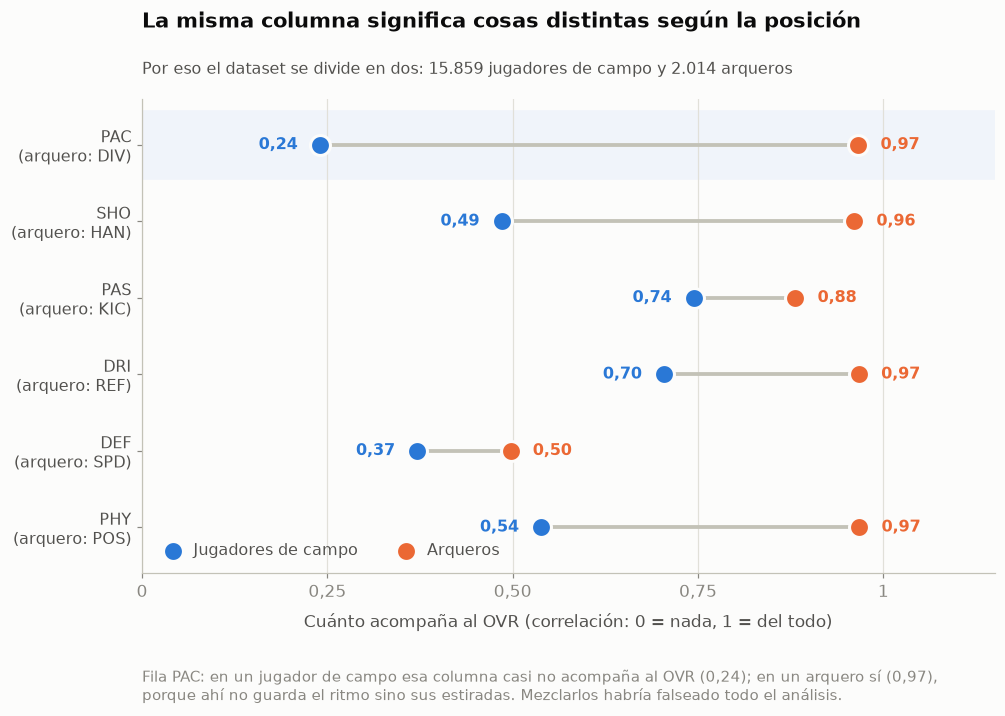

In [35]:
CARAS = ["pac", "sho", "pas", "dri", "def", "phy"]
NOMBRE_GK = ["diving", "handling", "kicking", "reflexes", "speed", "positioning"]
SIGLA_GK = ["DIV", "HAN", "KIC", "REF", "SPD", "POS"]

corr_campo = [campo[c].corr(campo["ovr"]) for c in CARAS]
corr_arqueros = [arqueros[f"gk_{n}"].corr(arqueros["ovr"]) for n in NOMBRE_GK]

fig, ax = plt.subplots(figsize=(10, 5.6))

# Fondo suave en la fila PAC: es el caso más extremo y queremos que el ojo vaya ahí
ax.add_patch(Rectangle((0, -0.45), 1.18, 0.9, color="#f0f4fa", zorder=0))

for i, (a, b) in enumerate(zip(corr_campo, corr_arqueros)):
    ax.plot([a, b], [i, i], color=GRIS, linewidth=2.5, zorder=1, solid_capstyle="round")

ax.scatter(corr_campo, range(len(CARAS)), s=170, color=AZUL, zorder=3,
           edgecolors=SUPERFICIE, linewidths=2, label="Jugadores de campo")
ax.scatter(corr_arqueros, range(len(CARAS)), s=170, color=NARANJA, zorder=3,
           edgecolors=SUPERFICIE, linewidths=2, label="Arqueros")

# Etiqueta directa de cada valor: nadie debería tener que leer el eje
for i, (a, b) in enumerate(zip(corr_campo, corr_arqueros)):
    (izq, col_izq), (der, col_der) = sorted([(a, AZUL), (b, NARANJA)])
    ax.text(izq - 0.03, i, f"{izq:.2f}".replace(".", ","), ha="right", va="center",
            fontsize=10.5, color=col_izq, fontweight="bold", zorder=4)
    ax.text(der + 0.03, i, f"{der:.2f}".replace(".", ","), ha="left", va="center",
            fontsize=10.5, color=col_der, fontweight="bold", zorder=4)

ax.set_yticks(range(len(CARAS)),
              [f"{c.upper()}\n(arquero: {s})" for c, s in zip(CARAS, SIGLA_GK)],
              fontsize=10.5, color=TINTA_SUAVE)
ax.set_ylim(5.6, -0.6)
ax.set_xlim(0, 1.15)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0], ["0", "0,25", "0,50", "0,75", "1"])
ax.set_xlabel("Cuánto acompaña al OVR (correlación: 0 = nada, 1 = del todo)", labelpad=8)
ax.xaxis.grid(True, zorder=0)
ax.set_axisbelow(True)

ax.legend(loc="lower left", ncol=2, frameon=False, fontsize=10.5,
          labelcolor=TINTA_SUAVE, handletextpad=0.3, columnspacing=2)

poner_titulo(ax, "La misma columna significa cosas distintas según la posición",
             "Por eso el dataset se divide en dos: 15.859 jugadores de campo y 2.014 arqueros")

ax.text(0, -0.20,
         "Fila PAC: en un jugador de campo esa columna casi no acompaña al OVR (0,24); en un arquero sí (0,97),\n"
         "porque ahí no guarda el ritmo sino sus estiradas. Mezclarlos habría falseado todo el análisis.",
         transform=ax.transAxes, fontsize=9.5, color=TINTA_TENUE, va="top", ha="left")

guardar(fig, "01_por_que_separamos_arqueros.png")
plt.show()

## Gráfico 2 — Qué pasó con los valores faltantes

Antes de limpiar había celdas vacías en 6 columnas. Ninguna era un error de carga:
cada una tenía una explicación, y por eso el dataset final no tiene ni un solo
faltante **sin haber inventado ningún dato**.

✓ 02_valores_faltantes.png


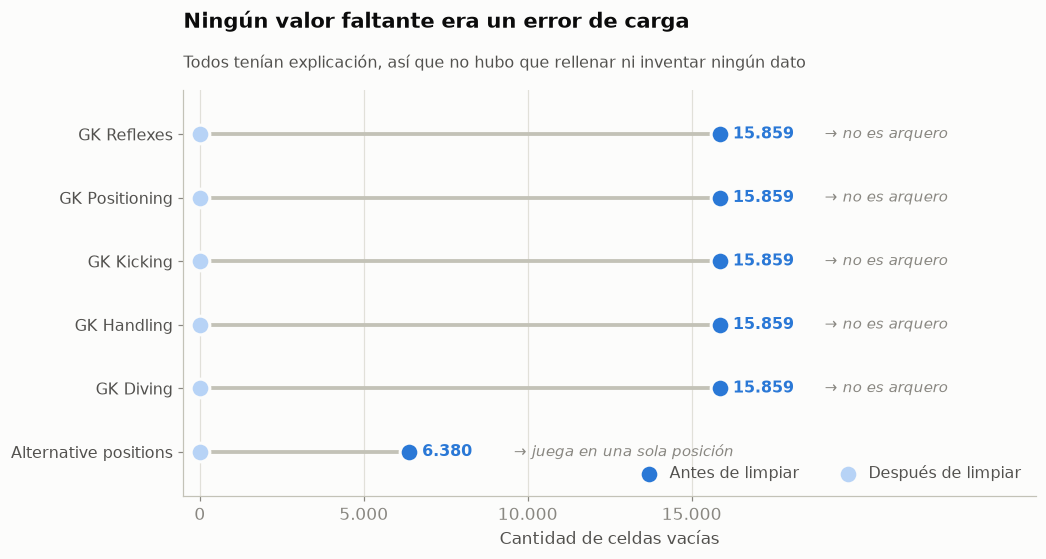

In [36]:
nulos_antes = jugadores_crudo.isna().sum()
nulos_antes = nulos_antes[nulos_antes > 0].sort_values()

EXPLICACIONES = {
    "Alternative positions": "juega en una sola posición",
    "GK Diving": "no es arquero",
    "GK Handling": "no es arquero",
    "GK Kicking": "no es arquero",
    "GK Positioning": "no es arquero",
    "GK Reflexes": "no es arquero",
}

fig, ax = plt.subplots(figsize=(10, 4.8))

for i, valor in enumerate(nulos_antes.values):
    ax.plot([0, valor], [i, i], color=GRIS, linewidth=2.5, zorder=1, solid_capstyle="round")

ax.scatter(nulos_antes.values, range(len(nulos_antes)), s=150, color=AZUL, zorder=3,
           edgecolors=SUPERFICIE, linewidths=2, label="Antes de limpiar")
ax.scatter([0] * len(nulos_antes), range(len(nulos_antes)), s=150, color=AZUL_CLARO,
           zorder=3, edgecolors=SUPERFICIE, linewidths=2, label="Después de limpiar")

for i, (col, valor) in enumerate(nulos_antes.items()):
    ax.text(valor + 400, i, miles(valor), ha="left", va="center",
            fontsize=10.5, color=AZUL, fontweight="bold")
    ax.text(valor + 3200, i, f"→ {EXPLICACIONES.get(col, '')}", ha="left", va="center",
            fontsize=9.5, color=TINTA_TENUE, style="italic")

ax.set_yticks(range(len(nulos_antes)), list(nulos_antes.index),
              fontsize=10.5, color=TINTA_SUAVE)
ax.set_ylim(-0.7, len(nulos_antes) - 0.3)
ax.set_xlim(-500, 25500)
ax.set_xticks([0, 5000, 10000, 15000])
ax.xaxis.set_major_formatter(FuncFormatter(miles))
ax.set_xlabel("Cantidad de celdas vacías")
ax.xaxis.grid(True, zorder=0)
ax.set_axisbelow(True)

ax.legend(loc="lower right", ncol=2, frameon=False, fontsize=10.5,
          labelcolor=TINTA_SUAVE, handletextpad=0.3, columnspacing=2)

poner_titulo(ax, "Ningún valor faltante era un error de carga",
             "Todos tenían explicación, así que no hubo que rellenar ni inventar ningún dato")

guardar(fig, "02_valores_faltantes.png")
plt.show()

## Gráfico 3 — Cómo quedó distribuido el OVR

Un panel por dataset. El eje vertical va en **porcentaje**, no en cantidad: como hay
ocho veces más jugadores de campo que arqueros, en cantidades absolutas el panel
derecho sería una línea plana y no se podría comparar la forma.

✓ 03_distribucion_ovr.png


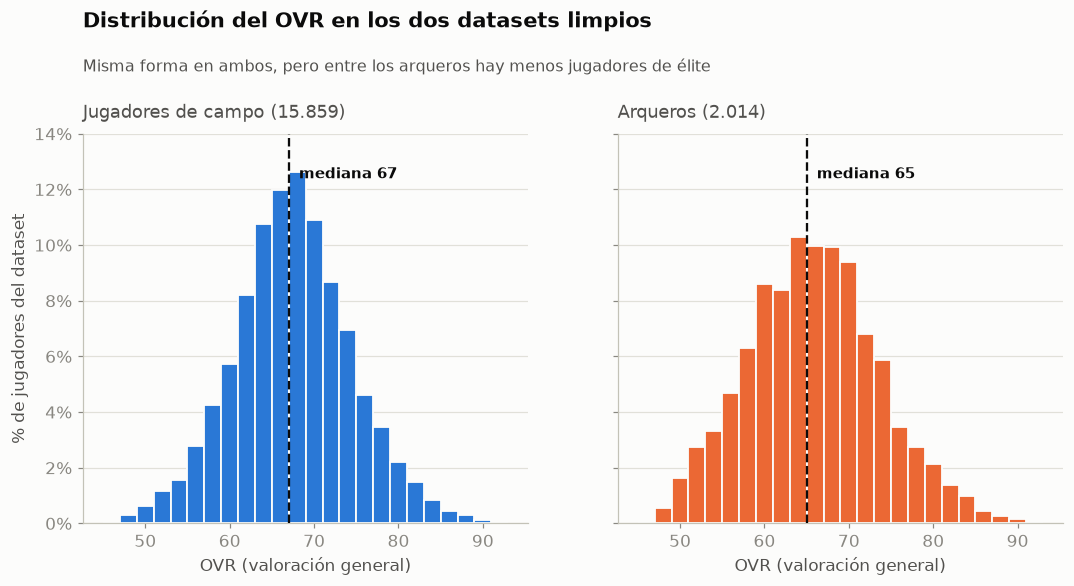

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharex=True, sharey=True)

paneles = [
    (axes[0], campo, f"Jugadores de campo ({miles(len(campo))})", AZUL),
    (axes[1], arqueros, f"Arqueros ({miles(len(arqueros))})", NARANJA),
]

for ax, df, titulo, color in paneles:
    pesos = [100 / len(df)] * len(df)  # cada jugador vale su % del dataset
    ax.hist(df["ovr"], bins=range(45, 95, 2), weights=pesos,
            color=color, edgecolor=SUPERFICIE, linewidth=1.2, zorder=2)
    mediana = df["ovr"].median()
    ax.axvline(mediana, color=TINTA, linewidth=1.5, linestyle="--", zorder=5)
    ax.text(mediana + 1.2, 12.4, f"mediana {mediana:.0f}", fontsize=10,
            color=TINTA, fontweight="bold")
    ax.text(0, 1.03, titulo, transform=ax.transAxes, fontsize=11.5,
            color=TINTA_SUAVE, va="bottom", ha="left")
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("OVR (valoración general)")

axes[0].set_ylabel("% de jugadores del dataset")
axes[0].set_ylim(0, 14)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v)}%"))

# Se suben más que en otros gráficos porque abajo están los títulos de cada panel
poner_titulo(axes[0], "Distribución del OVR en los dos datasets limpios",
             "Misma forma en ambos, pero entre los arqueros hay menos jugadores de élite",
             alto=(1.26, 1.15))

guardar(fig, "03_distribucion_ovr.png")
plt.show()

## Gráfico 4 — Cuántos jugadores hay de cada posición

Usamos **énfasis**: el grupo que separamos (GK) va en color y el resto en gris. Así
el gráfico cuenta una sola cosa en lugar de doce.

✓ 04_jugadores_por_posicion.png


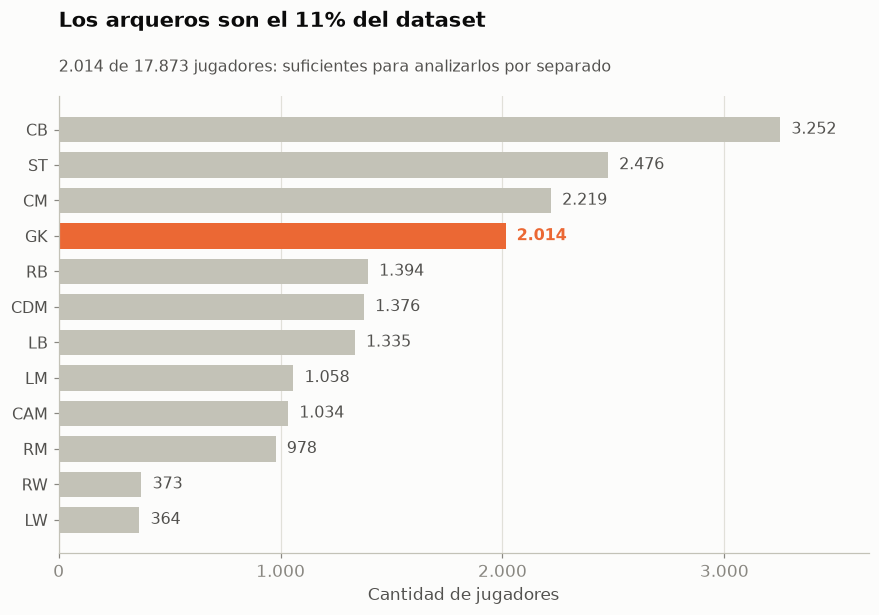

In [38]:
conteo = jugadores["position"].value_counts().sort_values()
porcentaje_gk = conteo["GK"] / conteo.sum()

fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.barh(range(len(conteo)), conteo.values, height=0.72,
        color=[NARANJA if pos == "GK" else GRIS for pos in conteo.index])

for i, (pos, valor) in enumerate(conteo.items()):
    es_gk = pos == "GK"
    ax.text(valor + 50, i, miles(valor), ha="left", va="center", fontsize=10.5,
            color=NARANJA if es_gk else TINTA_SUAVE,
            fontweight="bold" if es_gk else "normal")

ax.set_yticks(range(len(conteo)), list(conteo.index), fontsize=10.5, color=TINTA_SUAVE)
ax.set_xlim(0, 3650)
ax.set_xticks([0, 1000, 2000, 3000])
ax.xaxis.set_major_formatter(FuncFormatter(miles))
ax.set_xlabel("Cantidad de jugadores")
ax.xaxis.grid(True, zorder=0)
ax.set_axisbelow(True)

poner_titulo(ax, f"Los arqueros son el {porcentaje_gk:.0%} del dataset",
             f"{miles(conteo['GK'])} de {miles(conteo.sum())} jugadores: suficientes para analizarlos por separado")

guardar(fig, "04_jugadores_por_posicion.png")
plt.show()

## Gráfico 5 — El cruce entre cartas promocionales y cartas base

El dataset de promos no trae ID, así que el cruce hubo que hacerlo por nombre. Este
gráfico muestra cuánto se ganó con cada pase.

✓ 05_cruce_cartas_promo.png


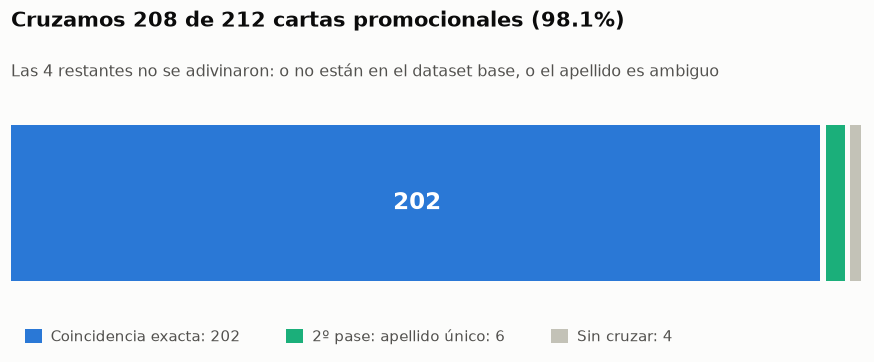

In [39]:
tramos = [
    ("Coincidencia exacta", cruzan_exacto, AZUL),
    ("2º pase: apellido único", cruzan - cruzan_exacto, AQUA),
    ("Sin cruzar", len(promo) - cruzan, GRIS),
]

fig, ax = plt.subplots(figsize=(10, 2.2))

izquierda = 0
for _, valor, color in tramos:
    ax.barh(0, valor, left=izquierda, color=color, height=0.5, zorder=2)
    izquierda += valor
    ax.barh(0, 1.4, left=izquierda - 0.7, color=SUPERFICIE, height=0.5, zorder=3)  # separador

ax.text(cruzan_exacto / 2, 0, str(cruzan_exacto), ha="center", va="center",
        fontsize=15, fontweight="bold", color="white", zorder=4)

# Leyenda nativa de matplotlib: reparte el espacio sola, así nunca se pisan las etiquetas
ax.legend(handles=[Patch(facecolor=color, label=f"{etiqueta}: {valor}")
                   for etiqueta, valor, color in tramos],
          loc="upper left", bbox_to_anchor=(0, -0.10), ncol=3, frameon=False,
          fontsize=10, labelcolor=TINTA_SUAVE, handlelength=1.1, handleheight=1.1,
          handletextpad=0.6, columnspacing=3)

ax.set_xlim(0, len(promo))
ax.set_ylim(-0.3, 0.3)
ax.axis("off")

poner_titulo(ax, f"Cruzamos {cruzan} de {len(promo)} cartas promocionales ({cruzan/len(promo):.1%})",
             "Las 4 restantes no se adivinaron: o no están en el dataset base, o el apellido es ambiguo",
             alto=(1.42, 1.16))

guardar(fig, "05_cruce_cartas_promo.png")
plt.show()

## Gráfico 6 — Qué hay en el dataset de cartas promocionales

Una vista rápida del segundo dataset ya limpio: cuántas cartas trae cada promo y
hasta dónde llega su OVR.

✓ 06_cartas_promo_por_tipo.png


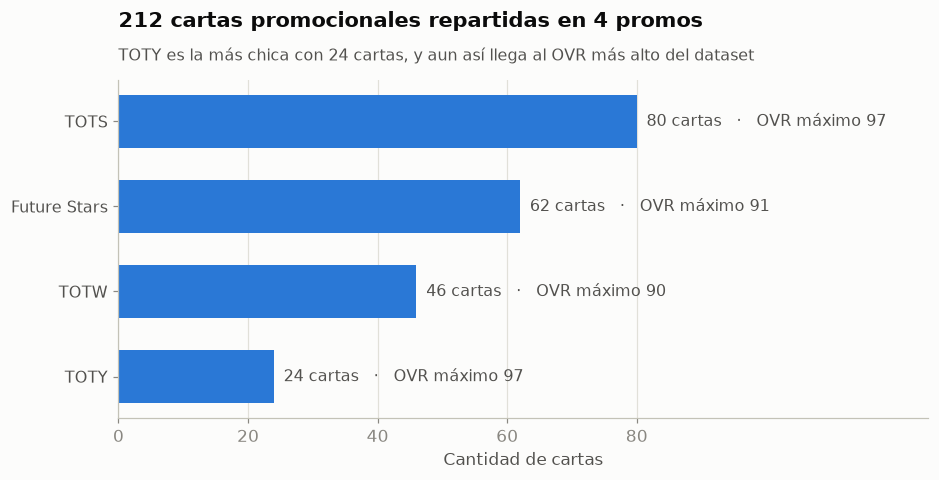

In [40]:
resumen_promo = (promo.groupby("promo_code", observed=True)
                      .agg(cartas=("card_ovr", "size"), ovr_max=("card_ovr", "max"))
                      .sort_values("cartas"))

fig, ax = plt.subplots(figsize=(9.5, 4))
ax.barh(range(len(resumen_promo)), resumen_promo["cartas"], color=AZUL, height=0.62)

for i, (_, fila) in enumerate(resumen_promo.iterrows()):
    ax.text(fila["cartas"] + 1.5, i,
            f"{int(fila['cartas'])} cartas   ·   OVR máximo {int(fila['ovr_max'])}",
            ha="left", va="center", fontsize=10.5, color=TINTA_SUAVE)

ax.set_yticks(range(len(resumen_promo)), list(resumen_promo.index),
              fontsize=10.5, color=TINTA_SUAVE)
ax.set_xlim(0, 125)
ax.set_xticks([0, 20, 40, 60, 80])
ax.set_xlabel("Cantidad de cartas")
ax.xaxis.grid(True, zorder=0)
ax.set_axisbelow(True)

poner_titulo(ax, f"{len(promo)} cartas promocionales repartidas en {promo['promo_code'].nunique()} promos",
             "TOTY es la más chica con 24 cartas, y aun así llega al OVR más alto del dataset")

guardar(fig, "06_cartas_promo_por_tipo.png")
plt.show()

---
Los seis PNG quedaron en `output/figuras/`, listos para arrastrar a las diapositivas.